In [264]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import plot_lines, plot_eer, plot_f1

df = pd.read_parquet(ROOT / "results" / "sweep.parquet")

# Slide 1: GMM-only comparison

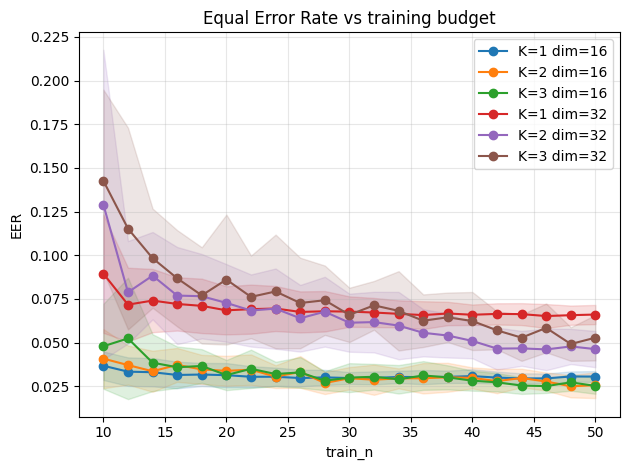

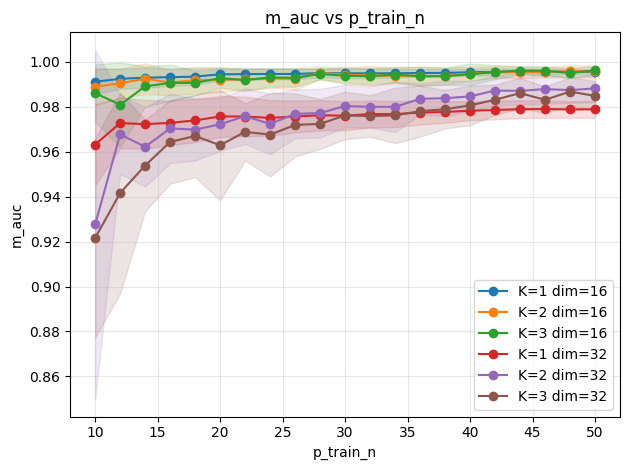

In [265]:
gmm_lines = [
    ("K=1 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("K=2 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("K=3 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("K=1 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 32}),
    ("K=2 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 32}),
    ("K=3 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag", "p_embedding_dim": 32}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 2: Best GMMs vs AE (full epochs) vs kNN

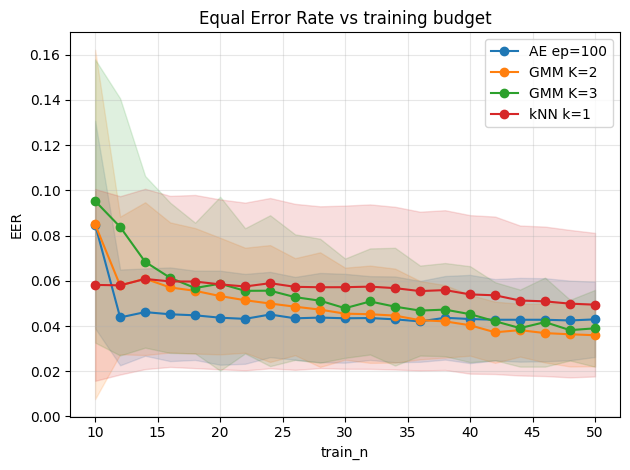

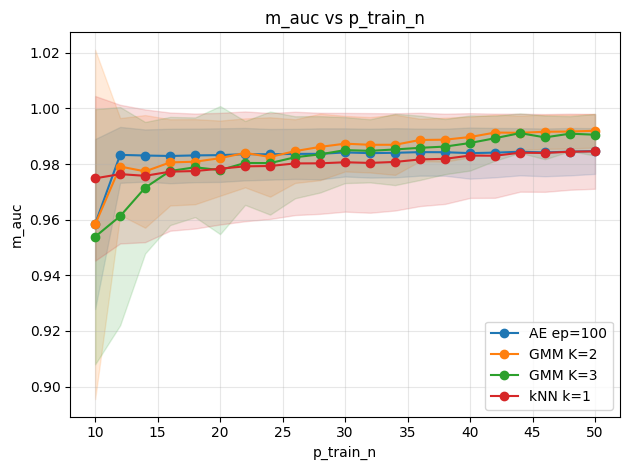

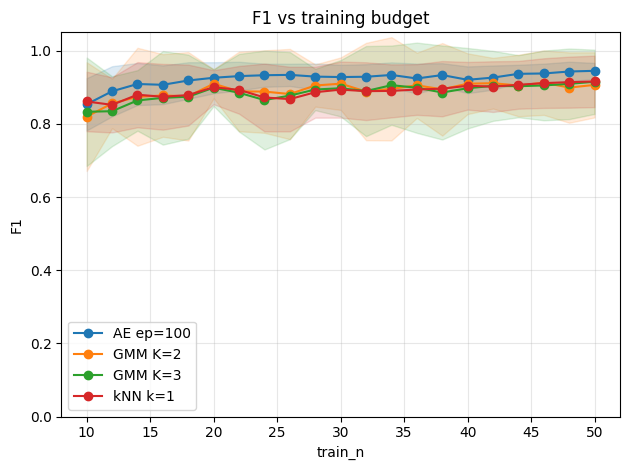

In [266]:
compare_lines = [
    ("AE ep=100",    {"p_adapter": "AutoencoderAdapter", "p_epochs": 100}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)

# Slide 3: Training MACs comparison

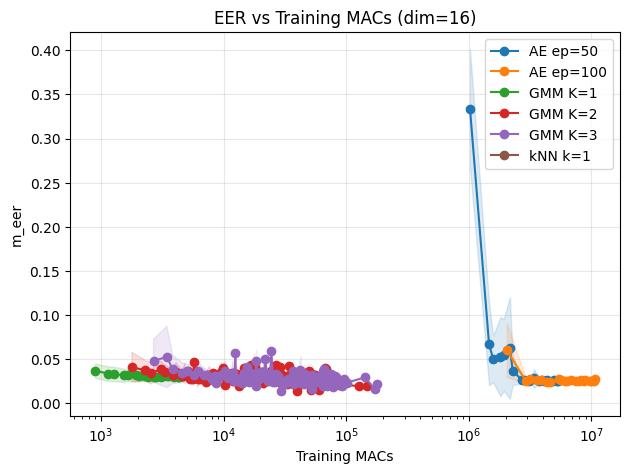

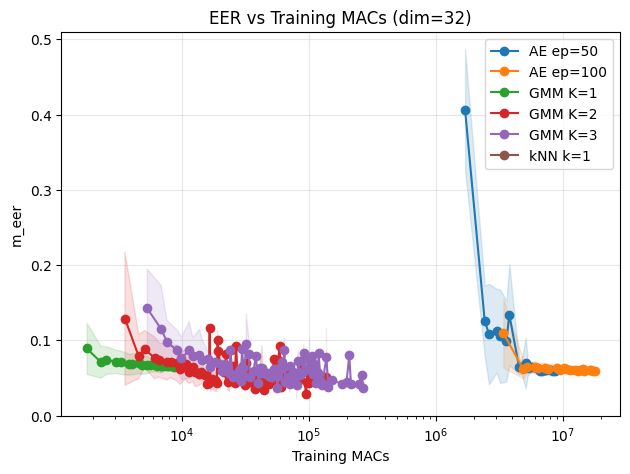

In [267]:
mac_lines = [
    ("AE ep=50",     {"p_adapter": "AutoencoderAdapter", "p_epochs": 50}),
    ("AE ep=100",    {"p_adapter": "AutoencoderAdapter", "p_epochs": 100}),
    ("GMM K=1",      {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
]

for dim in [16, 32]:
    sub = df[df["p_embedding_dim"] == dim]
    plot_lines(sub, x="m_training_macs", y="m_eer", lines=mac_lines)
    plt.xscale("log")
    plt.title(f"EER vs Training MACs (dim={dim})")
    plt.xlabel("Training MACs")

plt.show()

# Slide 4: MAC-fair comparison (AE ep=1,2 vs GMM)

AE at ep=1 already uses ~2x the training MACs of GMM K=3, yet GMM reaches EER ~0.025 while AE ep=1 is stuck at ~0.38. AE needs ep=50 (~100x GMM's MACs) to match.

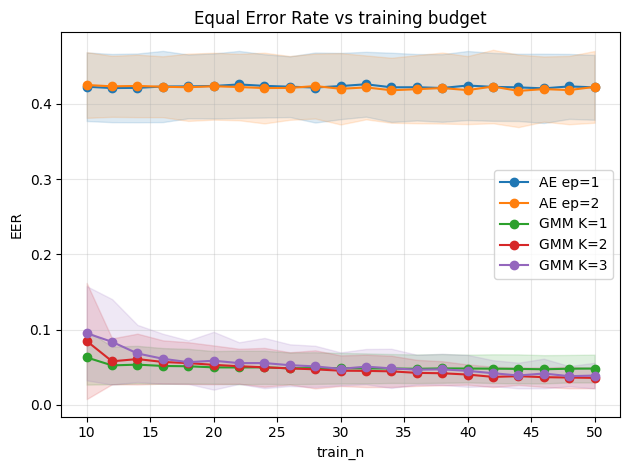

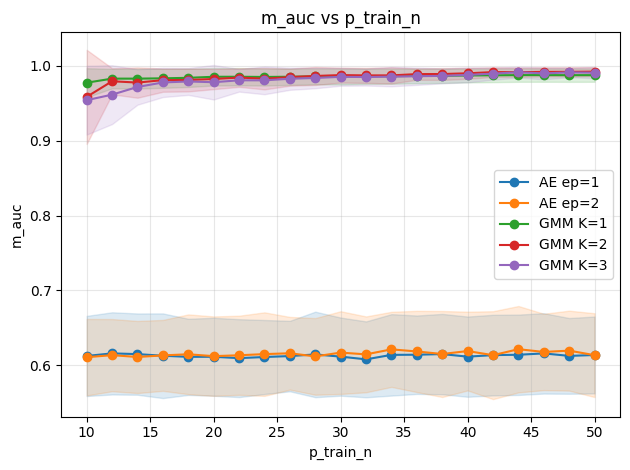

In [268]:
fair_lines = [
    ("AE ep=1",      {"p_adapter": "AutoencoderAdapter", "p_epochs": 1}),
    ("AE ep=2",      {"p_adapter": "AutoencoderAdapter", "p_epochs": 2}),
    ("GMM K=1",      {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)